# Jupyter Lab to the extended StaticRobotModel class

This jupyter lab demonstrates the capabilities of the StaticRobotModel which acts as a wrapper for the Sven Lilge repository on GitHub. The latter can be accessed [here](https://github.com/SvenLilge/tdcr-modeling). In the aforementioned repository, 5 different modeling approaches for tendon-driven continuum robots (TDCR) are implemented in C++. This class provides some binding code by utilizing the pybind11 library.

### System Setup
Since the computation of the different robot models requires the GSL and the Eigen library, these must be installed first. Therefore, follow this link 
https://solarianprogrammer.com/2020/01/26/getting-started-gsl-gnu-scientific-library-windows-macos-linux/

### Special care for Mac using the M1 chip/arm architecture
During development, we encountered several difficulties running the code; we used Pycharm.
1. We installed `brew` in a terminal session that ran under rosetta
2. In Pycharm, we changed the shell path under Preferences -> Tools -> Terminal, "Shell path" was set to `env /usr/bin/arch -x86_64 /bin/zsh --login` to run the pycharm terminal under rosetta as well.
3. After 2. start a new terminal within Pycharm; otherwise, your changes won't be applied

### Initialize the packages
The pytdcrsv project is structured in the /src format and a proper tox.ini file is provided. Hence, one might just run 


        usr@machine: pathTo/pytdcrsv/Code$ tox

        
in the /Code folder. This will trigger three successive steps:

1. Create a virtual environment due to the pyproject.toml file to make sure pybind11 is (temporarily) installed.
2. Install the project and its dependencies (specified within the setup.py) in the virtual environment .tox/test
3. Run the provided tests

After the virtual environment is setup and ready to use, select it as your interpreter (like you would do with any virtual environment)

#### Import all needed modules:

In [1]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pytest as pt
import tdrpyb as tdr
from pytdcrsv.static_robot_model import StaticRobotModel
from pytdcrsv.trajectory_generation import InitValuesVCRef

from IPython.display import display

### Implemented models
- VC <=> Cosserat rod with fully constraint tendon routing
- CC <=> Constant curvature model with fully constraint tendon routing
##### Models
The following table summarises all modelling approaches within this class.
| Name                                  | Implemented   |  Argument in Class |
|---------------------------------------|---------------|--------------------|
| Cosserat rod                          | yes           | "VC"
| Subsegment Cosserat rod (reference)   | yes           | "VC_Ref"
| Pseudo Rigid Body                     | yes           | "PRB"
| Constant Curvature                    | yes           | "CC"
| Piecewise Constant Curvature          | yes           | "PCC"

##### Available binding Code for the Sven Lilge Repository
While this table summarises the C++ functions that are currently bonded
| Name                              | Binding (local) | 
|-----------------------------------|-----------------|
| TendonDrivenRobot()               | yes             |
| setRobotParameters()              | yes             |
| forwardKinematics_pyb()           | yes             | 
| getTendonDisplacements_storage()  | yes             |
| getCurrentConfig()                | no              |
| getDiskFrames()                   | yes             |
| Robot model enumeration           | yes             |


It is essential to run the Cosserat rod to the constant curvature model in advance since the latter is based on the tendon displacements calculated from the Cosserat rod model (fully constrained tendon routing). In the next version of the program, this shortcoming will be improved by automatically triggering the model as mentioned above.

### Define parameters
First, specify the robot parameters/external forces and torques. Here, we use the Cosserat rod and constant curvature models.

In [2]:
segment_length__m = 0.2
f__n = np.array([0, 0, 0])
l__Nm = np.array([0, 0, 0])

tendon_radius__m = 6*1e-3

e__n_per_m2 = 80*1e9
g__m_per_s2 = 9.81
modelling_approach_vc = "VC"
modelling_approach_cc = "CC"

### Instatiate robot models

In [3]:
robot_vc = StaticRobotModel(segment_length__m=
                           InitValuesVCRef.segment_length__m,
                           f__n=InitValuesVCRef.f__n,
                           l__Nm=InitValuesVCRef.l__Nm,
                           youngs_modulus__n_per_m2=
                           InitValuesVCRef.youngs_modulus__n_per_m2,
                           pradius_disks__m=
                            InitValuesVCRef.pradius_disks__m,
                           ro__m=InitValuesVCRef.ro__m,
                           modelling_approach="VC"
                           )

robot_cc = StaticRobotModel(segment_length__m=
                           InitValuesVCRef.segment_length__m,
                           f__n=InitValuesVCRef.f__n,
                           l__Nm=InitValuesVCRef.l__Nm,
                           youngs_modulus__n_per_m2=
                           InitValuesVCRef.youngs_modulus__n_per_m2,
                           pradius_disks__m=
                            InitValuesVCRef.pradius_disks__m,
                           ro__m=InitValuesVCRef.ro__m,
                           modelling_approach="CC"
                           )

### Define actuation
Define the actuation vector for one control. Since the tendon-driven robot model consists of two segments, actuated by three tendons each, one control is made up of 6 values: The tendon forces in [Nm]
$$
\vec{q} = \begin{pmatrix}
            q_{1,1} \\
            q_{1,2} \\
            q_{1,3} \\  
            q_{2,1}\\
            q_{2,2}\\ 
            q_{2,3}
            \end{pmatrix}
$$

In [4]:
q = np.array([4, 0, 0, 0, 1, 0]).reshape((6,1))

### Compute poses
One run calculates all disk frames. The corresponding function returns an array (lengths equals amount of controls $\vec{q}_i$), where each entry indicates if the calculation (C++ functions) of pose $i$ was successful. Tendon displacements are stored in the class variable `tendon_displacements` (DataFrame) during the VC model calculation.

In [5]:
success_vc = robot_vc.calc_pose_from_ctrl(act=q)
tendon_displacements = robot_vc.tendon_displacement
success_cc = robot_cc.calc_pose_from_ctrl(act=tendon_displacements)

print(success_vc)
print(success_cc)
tendon_displacements

[ True]
[ True]


0    [0.0034379859410419156, -0.001157549610287495,...
Name: tendon_displacement, dtype: object

To receive the calculated disk frames as 7-dimensional state vectors (where the first three entries denote the position while the remaining entries denote the orientation (unit quaternion) of the considered frame - with respect to the robot's base frame)
$$
\vec{x} = \begin{pmatrix}
            x\\
            y\\
            z\\
            w\\
            a\\
            b\\
            c
            \end{pmatrix}            
$$
you only have to access the robots frames_df attribute.

In [6]:
x_vc = robot_vc.frames_df
x_cc = robot_cc.frames_df
display(x_vc)

,actuation_set,ctrl,disk_00,disk_01,disk_02,disk_03,disk_04,disk_05,disk_06,disk_07,...,disk_13,disk_14,disk_15,disk_16,disk_17,disk_18,disk_19,ee,success,tendon_displacement
0,0,"[4, 0, 0, 0, 1, 0]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[5.7393726466363524e-05, 0.0003203174521523600...","[0.00022946682617666335, 0.0012806666061505267...","[0.0005158952613614928, 0.0028792389837399342,...","[0.0009161396471187615, 0.0051130242424919665,...","[0.0014294462671576658, 0.007977815844763191, ...","[0.00205484849315857, 0.011468218979257688, 0....","[0.0027911686050758663, 0.015577660720274583, ...",...,"[0.009507504660369684, 0.04988034053781763, 0....","[0.011023724500178456, 0.0558681639159853, 0.1...","[0.012655070589866865, 0.061791907174130224, 0...","[0.014401415498206534, 0.0676511075786244, 0.2...","[0.016262622810916214, 0.07344530743749496, 0....","[0.018238547141316876, 0.07917405413617744, 0....","[0.020329034141687675, 0.08483690017287251, 0....","[0.022533920515321902, 0.09043340319350328, 0....",True,"[0.0034379859410419156, -0.001157549610287495,..."


### Print data frames which hold the disk frames per actuation

##### Cosserat rod

In [7]:
display(x_vc)

,actuation_set,ctrl,disk_00,disk_01,disk_02,disk_03,disk_04,disk_05,disk_06,disk_07,...,disk_13,disk_14,disk_15,disk_16,disk_17,disk_18,disk_19,ee,success,tendon_displacement
0,0,"[4, 0, 0, 0, 1, 0]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[5.7393726466363524e-05, 0.0003203174521523600...","[0.00022946682617666335, 0.0012806666061505267...","[0.0005158952613614928, 0.0028792389837399342,...","[0.0009161396471187615, 0.0051130242424919665,...","[0.0014294462671576658, 0.007977815844763191, ...","[0.00205484849315857, 0.011468218979257688, 0....","[0.0027911686050758663, 0.015577660720274583, ...",...,"[0.009507504660369684, 0.04988034053781763, 0....","[0.011023724500178456, 0.0558681639159853, 0.1...","[0.012655070589866865, 0.061791907174130224, 0...","[0.014401415498206534, 0.0676511075786244, 0.2...","[0.016262622810916214, 0.07344530743749496, 0....","[0.018238547141316876, 0.07917405413617744, 0....","[0.020329034141687675, 0.08483690017287251, 0....","[0.022533920515321902, 0.09043340319350328, 0....",True,"[0.0034379859410419156, -0.001157549610287495,..."


##### Constant Curvature


In [8]:
display(x_cc)

,actuation_set,ctrl,disk_00,disk_01,disk_02,disk_03,disk_04,disk_05,disk_06,disk_07,...,disk_12,disk_13,disk_14,disk_15,disk_16,disk_17,disk_18,disk_19,ee,success
0,0,"[0.00343799, -0.00115755, -0.00221806, -0.0002...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[5.7400734655723326e-05, 0.00032035631118708, ...","[0.00022949483172321199, 0.001280821894846903,...","[0.0005159581741088314, 0.00287958783760698, 0...","[0.0009162512449578629, 0.005113643069479487, ...","[0.0014296201437650918, 0.007978780034824216, ...","[0.00205509800624943, 0.011469602616738385, 0....","[0.0027915068253184018, 0.015579536299948606, ...",...,"[0.008107370069842648, 0.043833529848183915, 0...","[0.009508430023155412, 0.04988539318111154, 0....","[0.011024737381937561, 0.05587364287930889, 0....","[0.012656173698239251, 0.06179781116432941, 0....","[0.014402611530690324, 0.06765743526351393, 0....","[0.01626391445445592, 0.07345205744614042, 0.2...","[0.018239937071893433, 0.07918122505918013, 0....","[0.020330525023910015, 0.08484449056265718, 0....","[0.022535515002021198, 0.09044141156460844, 0....",True


#### Calculate multiple poses in one run
And use a fancy display option if you like. This is not a requirement in the setup.py since the installation process is long due to the Qt dependency. However, if you don't mind waiting a little bit more, you can install it through the jupyter environment 


        usr@machine: pathTo/paper_ba_wenner/Code$ tox -e jupyter

It will be installed by tox because of the ```deps``` field in the __tox.ini__ configuration file.

In [9]:

q1 = np.array([1, 2, 0, 3, 0, 1]).reshape((6,1))
q2 = np.array([0, 2, 3, 0, 0, 1]).reshape((6,1))
q = np.concatenate((q1, q2), axis=0)

robot_vc = StaticRobotModel(segment_length__m=
                           InitValuesVCRef.segment_length__m,
                           f__n=InitValuesVCRef.f__n,
                           l__Nm=InitValuesVCRef.l__Nm,
                           youngs_modulus__n_per_m2=
                           InitValuesVCRef.youngs_modulus__n_per_m2,
                           pradius_disks__m=
                            InitValuesVCRef.pradius_disks__m,
                           ro__m=InitValuesVCRef.ro__m,
                           modelling_approach=modelling_approach_vc
                           )

success_vc = robot_vc.calc_pose_from_ctrl(act=q)
print(success_vc)

if False:
    try:
        from pandasgui import show
        show(robot_vc.frames_df)
    except ImportError:
        display(robot_vc.frames_df)
else:
    display(robot_vc.frames_df)

[ True  True]


,actuation_set,ctrl,disk_00,disk_01,disk_02,disk_03,disk_04,disk_05,disk_06,disk_07,...,disk_13,disk_14,disk_15,disk_16,disk_17,disk_18,disk_19,ee,success,tendon_displacement
0,0,"[1, 2, 0, 3, 0, 1]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[9.566368190179169e-05, 0.0001656944301913924,...","[0.0003825924595681002, 0.0006626698654346138,...","[0.0008605995669858299, 0.0014906028114255163,...","[0.001529373861233866, 0.002648954346451556, 0...","[0.0023884800250102804, 0.004136970472193061, ...","[0.003437358849987233, 0.005953682604522472, 0...","[0.00467532760080912, 0.008097908203982068, 0....",...,"[0.014655574124888653, 0.027769445638159036, 0...","[0.016127590773962152, 0.03217288614066546, 0....","[0.017477473921971607, 0.03689271326837219, 0....","[0.0187044854842116, 0.04192634631735051, 0.23...","[0.01980795455958947, 0.04727103300132572, 0.2...","[0.020787277797454002, 0.0529238509565769, 0.2...","[0.02164191972748898, 0.05888170933983109, 0.2...","[0.0223714130524912, 0.0651413505182783, 0.289...",True,"[0.0017843034306082861, 1.669914559729313e-05,..."
1,0,"[0, 2, 3, 0, 0, 1]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]","[-0.0001339216657248489, -0.000254050405114968...","[-0.0005354902434060413, -0.001015829035287847...","[-0.0012041167674702964, -0.002284218654628419...","[-0.0021388205937174685, -0.004057359010145452...","[-0.0033382308375605263, -0.00633264955993689,...","[-0.004800588384609553, -0.009106753287120642,...","[-0.00652374847065126, -0.01237560159391303, 0...",...,"[-0.02157125338977989, -0.04023908092568793, 0...","[-0.024572413071464048, -0.04540210324466743, ...","[-0.027683707075202908, -0.0506226360402413, 0...","[-0.03090489235790765, -0.05590027153292056, 0...","[-0.03423571729237433, -0.06123459748261775, 0...","[-0.03767592168694022, -0.06662519722084567, 0...","[-0.04122523680580918, -0.0720716496832621, 0....","[-0.04488338539004452, -0.07757352944255785, 0...",True,"[-0.002690239072054984, 0.00013782990859714794..."


### Calculate trajectories and visualize trajectories


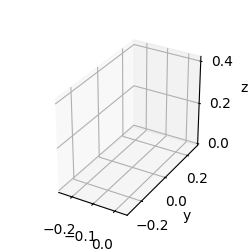

In [10]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

from pytdcrsv.visualize_robot import VisualizeRobot
from pytdcrsv.trajectory_generation import InitValuesVCRef, GenerateTrajectory
from pytdcrsv.static_robot_model import StaticRobotModel
import matplotlib.pyplot as plt
from IPython.display import HTML
import numpy as np

 # Create robot
segment_length__m = 0.2
f__n = np.array([0, 0, 0])
l__Nm = np.array([0, 0, 0])
tendon_radius__m = 6 * 1e-3
i_m__per_m4 = np.pi * (0.5 * 1e-3) ** 4 / 4
e__n_per_m2 = 80 * 1e9
g__m_per_s2 = 9.81
modelling_approach_vc = "VC"
# modelling_approach_cc = "CC"

robot_vc = StaticRobotModel(segment_length__m=segment_length__m,
                            f__n=f__n,
                            l__Nm=l__Nm,
                            modelling_approach=modelling_approach_vc)

q1 = np.array([0, 0, 0, 0, 0, 4])
q2 = np.array([0, 0, 0, 0, 4, 0])
q3 = np.array([3, 0, 4, 0, 0, 0])

steps = 3
q1 = np.concatenate([s * np.array([5, 0, 0, 0, 0, 0]) for s in
                         np.linspace(0, 1, 10)]
                        )
q2 = np.concatenate([q1[-6:] + s * np.array([-5, 0, 0, 0, 5, 5]) for s in
                         np.linspace(0, 1, 10)]
                        )
q3 = np.concatenate([q2[-6:] + s * np.array([0, 0, 5, 0, -5, -5]) for s in
                         np.linspace(0, 1, 10)]
                        )

q = np.concatenate((q1, q2, q3))
success_vc = robot_vc.calc_pose_from_ctrl(act=q)

# Visualilze robot
vrob = VisualizeRobot(robot=robot_vc)
anim = vrob.animate_robot(interval=200)
#HTML(anim.to_html5_video())